# Testing Version 2.0 :D

In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.gridspec as gridspec

#
from Calculations_Functions import proportions_from_filename, metrics_table
from matplotlib.colors import ListedColormap
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [2]:
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)

Functions for comparisons :D

Filenames for Ratio Testing:

- Ratio MC = 0.012

- Ratio MC = 0.2

- Ratio MC = 0.4

Keep $\tau = 0.01$ and the Sinking Velocity of marine and sewage particles to 5.52 and 12.84 respectively

Note: The bigger the Ratio, less colloids into the water column

In [3]:
filenames_ratio_testing = ['/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_185_days_full_updated_kernel_ratio_0_012.zarr',
                           '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_185_days_full_updated_kernel_ratio_0_2.zarr',
                           '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_185_days_full_updated_kernel_ratio_0_4.zarr']

In [4]:
run_ratio_0_012 = proportions_from_filename(filename = filenames_ratio_testing[0])
run_ratio_0_2 = proportions_from_filename(filename = filenames_ratio_testing[1])
run_ratio_0_4 = proportions_from_filename(filename = filenames_ratio_testing[2])
#
table_ratio_0_012  = metrics_table(filename = filenames_ratio_testing[0], plot = False)
table_ratio_0_2  = metrics_table(filename = filenames_ratio_testing[1], plot = False)
table_ratio_0_4  = metrics_table(filename = filenames_ratio_testing[2], plot = False)

In [5]:
water_ratio_0_012, sediment_ratio_0_012 =  run_ratio_0_012['Sewage W.C.'] + run_ratio_0_012['Colloidal W.C.'] + run_ratio_0_012['Marine W.C.'] , run_ratio_0_012['Sewage S.'] + run_ratio_0_012['Colloidal S.'] + run_ratio_0_012['Marine S.']
water_ratio_0_2, sediment_ratio_0_2 =  run_ratio_0_2['Sewage W.C.'] + run_ratio_0_2['Colloidal W.C.'] + run_ratio_0_2['Marine W.C.'] , run_ratio_0_2['Sewage S.'] + run_ratio_0_2['Colloidal S.'] + run_ratio_0_2['Marine S.']
water_ratio_0_4, sediment_ratio_0_4 =  run_ratio_0_4['Sewage W.C.'] + run_ratio_0_4['Colloidal W.C.'] + run_ratio_0_4['Marine W.C.'] , run_ratio_0_4['Sewage S.'] + run_ratio_0_4['Colloidal S.'] + run_ratio_0_4['Marine S.']

In [6]:
#
data_ratio_0_012 = xr.open_zarr(filenames_ratio_testing[0])
wc_ratio_0_012 = data_ratio_0_012.where((data_ratio_0_012.status < 4)& (data_ratio_0_012.status > 0))
sed_ratio_0_012 = data_ratio_0_012.where((data_ratio_0_012.status > 10))
data_ratio_0_2 = xr.open_zarr(filenames_ratio_testing[1])
wc_ratio_0_2 = data_ratio_0_2.where((data_ratio_0_2.status < 4)& (data_ratio_0_2.status > 0))
sed_ratio_0_2 = data_ratio_0_2.where((data_ratio_0_2.status > 10))
data_ratio_0_4 = xr.open_zarr(filenames_ratio_testing[2])
wc_ratio_0_4 = data_ratio_0_4.where((data_ratio_0_4.status < 4)& (data_ratio_0_4.status > 0))
sed_ratio_0_4 = data_ratio_0_4.where((data_ratio_0_4.status > 10))
#

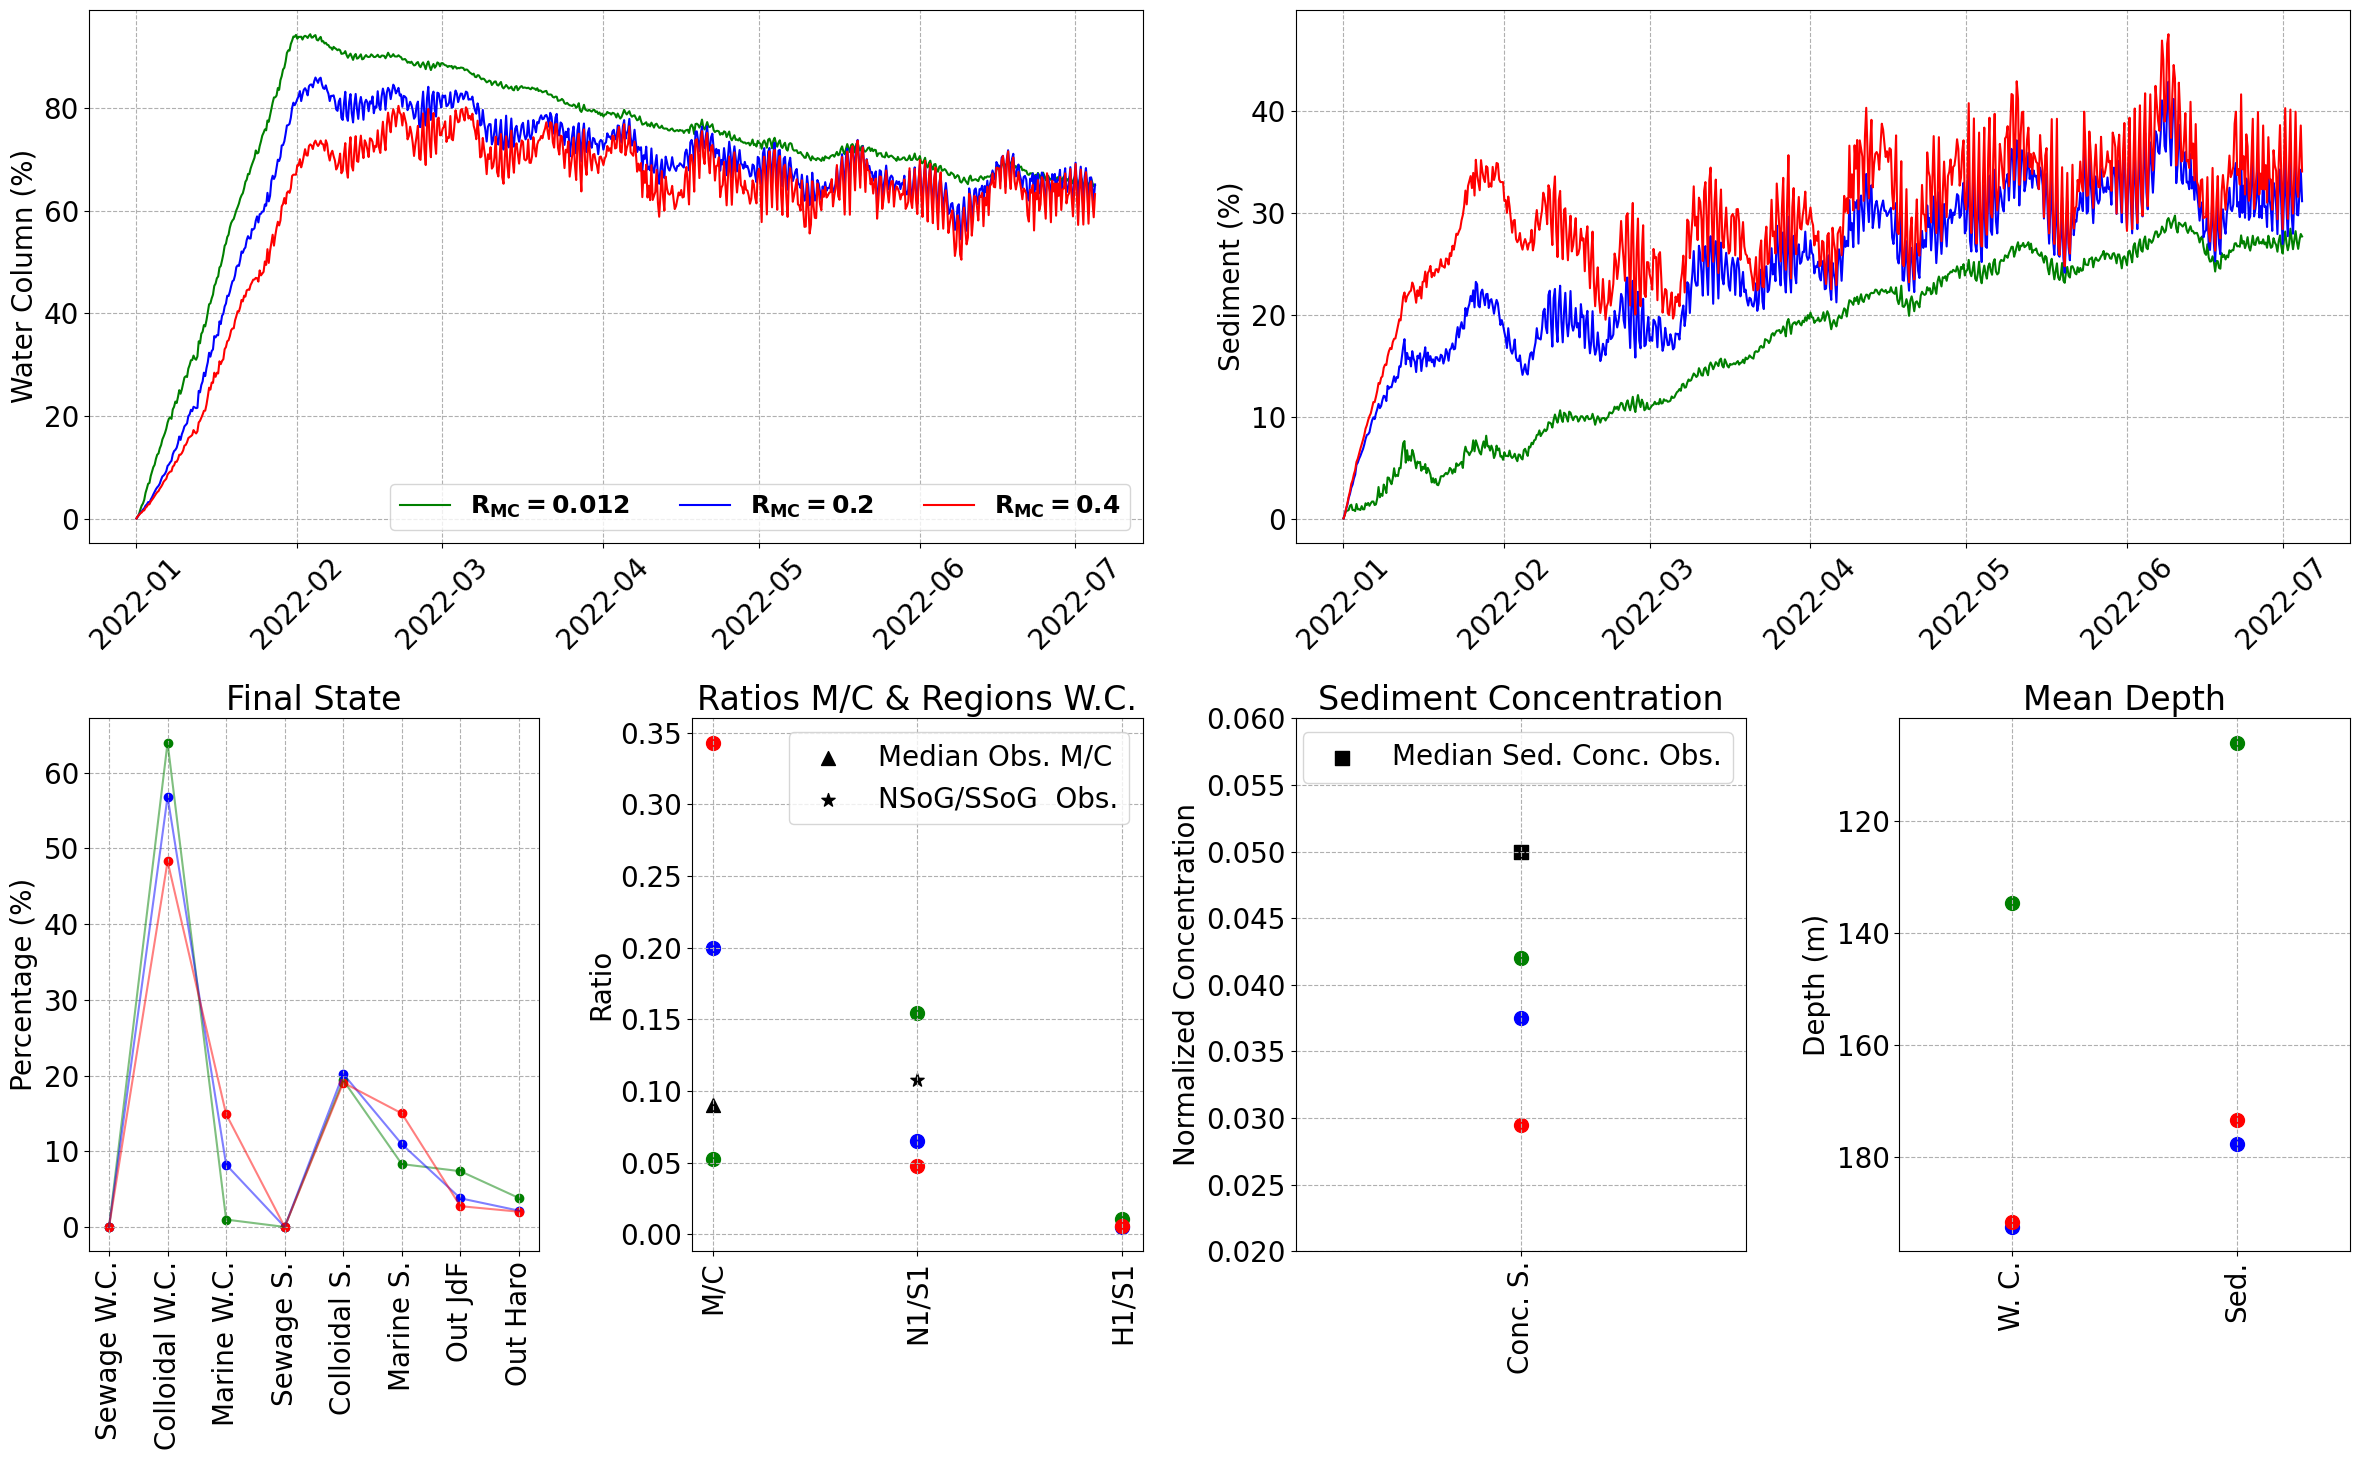

In [7]:
plt.rcParams.update({'font.size': 20})

fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(2, 8, height_ratios=[1,1])

# === Top row (2 panels) ===
ax1 = fig.add_subplot(gs[0, 0:4])
ax2 = fig.add_subplot(gs[0, 4:8])

# === Middle row (3 panels) ===
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])
ax6 = fig.add_subplot(gs[1, 6:8])
# --- Top left plot (Water Column) ---
ax1.plot(water_ratio_0_012, 'g', label=rf"$\mathbf{{R_{{MC}} = 0.012}}$")
ax1.plot(water_ratio_0_2, 'b', label=rf"$\mathbf{{R_{{MC}} = 0.2}}$")
ax1.plot(water_ratio_0_4, 'r', label=rf"$\mathbf{{R_{{MC}} = 0.4}}$")
ax1.grid(linestyle='--')
ax1.set_ylabel('Water Column (%)')
ax1.legend(loc = 'lower right', ncol = 3, fontsize = 18)
ax1.tick_params(axis='x', rotation=45)

# --- Top right plot (Sediment) ---
ax2.plot(sediment_ratio_0_012, 'g')
ax2.plot(sediment_ratio_0_2, 'b')
ax2.plot(sediment_ratio_0_4, 'r')
ax2.grid(linestyle='--')
ax2.set_ylabel('Sediment (%)')
ax2.tick_params(axis='x', rotation=45)

# --- Middle plots ---
# Middle left
ax3.scatter(run_ratio_0_012.columns[1:], run_ratio_0_012.iloc[-1][1:].values, c='g')
ax3.scatter(run_ratio_0_2.columns[1:], run_ratio_0_2.iloc[-1][1:].values, c='b')
ax3.scatter(run_ratio_0_4.columns[1:], run_ratio_0_4.iloc[-1][1:].values, c='r')
#
ax3.plot(run_ratio_0_012.columns[1:], run_ratio_0_012.iloc[-1][1:].values, color='g', alpha = .5)
ax3.plot(run_ratio_0_2.columns[1:], run_ratio_0_2.iloc[-1][1:].values, color='b', alpha = .5)
ax3.plot(run_ratio_0_4.columns[1:], run_ratio_0_4.iloc[-1][1:].values, color='r', alpha = .5)
ax3.grid(linestyle='--')
ax3.tick_params(axis='x', rotation=90)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Final State')

# Middle center
ax4.scatter(table_ratio_0_012.columns[[1,3,4]], table_ratio_0_012.loc[0].values[[1,3,4]], color='g', s=100)
ax4.scatter(table_ratio_0_2.columns[[1,3,4]], table_ratio_0_2.loc[0].values[[1,3,4]], color='b', s=100)
ax4.scatter(table_ratio_0_4.columns[[1,3,4]], table_ratio_0_4.loc[0].values[[1,3,4]], color='r', s=100)
ax4.scatter(table_ratio_0_012.columns[1], 0.09, c='k', marker = '^', s = 100, label = 'Median Obs. M/C')
ax4.scatter(table_ratio_0_012.columns[3], 0.108, c='k', marker = '*', s = 100, label = 'NSoG/SSoG  Obs.')
ax4.grid(linestyle='--')
ax4.tick_params(axis='x', rotation=90)
ax4.legend()
ax4.set_ylabel('Ratio')
ax4.set_title('Ratios M/C & Regions W.C.')

#
ax5.scatter(table_ratio_0_012.columns[2], table_ratio_0_012.loc[0].values[2], color='g', s=100)
ax5.scatter(table_ratio_0_2.columns[2], table_ratio_0_2.loc[0].values[2], color='b', s=100)
ax5.scatter(table_ratio_0_4.columns[2], table_ratio_0_4.loc[0].values[2], color='r', s=100)
ax5.scatter(table_ratio_0_012.columns[2], 0.05, c='k', marker = 's', s = 100, label = 'Median Sed. Conc. Obs.') # Median of normalized obs. concentrations
ax5.grid(linestyle='--')
ax5.legend()
ax5.tick_params(axis='x', rotation=90)
ax5.set_ylabel('Normalized Concentration')
ax5.set_ylim([0.02, 0.06])
ax5.set_title('Sediment Concentration')


# Middle right
ax6.scatter(table_ratio_0_012.columns[-2:], table_ratio_0_012.loc[0].values[-2:], color='g', s=100)
ax6.scatter(table_ratio_0_2.columns[-2:], table_ratio_0_2.loc[0].values[-2:], color='b', s=100)
ax6.scatter(table_ratio_0_4.columns[-2:], table_ratio_0_4.loc[0].values[-2:], color='r', s=100)
ax6.grid(linestyle='--')
ax6.set_xlim([-.5, 1.5])
ax6.tick_params(axis='x', rotation=90)
ax6.invert_yaxis()
ax6.set_ylabel('Depth (m)')
ax6.set_title('Mean Depth')

#
#
plt.tight_layout()

plt.show()



Filenames for $\tau$ Testing:

- $\tau$ = 0.01

- $\tau$ = 0.05

- $\tau$ = 0.25

Keep Ratio MC = 0.2 and the Sinking Velocity of marine and sewage particles to 5.52 and 12.84 respectively

Note: The bigger $\tau$ is, more difficult is for the particles to resuspend

In [8]:
filenames_tau_testing = ['/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_185_days_full_updated_kernel_ratio_0_2.zarr',
                         '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_185_days_full_updated_kernel_tau_0_05.zarr',
                         '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_185_days_full_updated_kernel_tau_0_25.zarr']

In [9]:
run_tau_0_01 = proportions_from_filename(filename = filenames_tau_testing[0])
run_tau_0_05 = proportions_from_filename(filename = filenames_tau_testing[1])
run_tau_0_25 = proportions_from_filename(filename = filenames_tau_testing[2])
#
table_tau_0_01  = metrics_table(filename = filenames_tau_testing[0], plot = False)
table_tau_0_05  = metrics_table(filename = filenames_tau_testing[1], plot = False)
table_tau_0_25  = metrics_table(filename = filenames_tau_testing[2], plot = False)

In [10]:
water_tau_0_01, sediment_tau_0_01 =  run_tau_0_01['Sewage W.C.'] + run_tau_0_01['Colloidal W.C.'] + run_tau_0_01['Marine W.C.'] , run_tau_0_01['Sewage S.'] + run_tau_0_01['Colloidal S.'] + run_tau_0_01['Marine S.']
water_tau_0_05, sediment_tau_0_05 =  run_tau_0_05['Sewage W.C.'] + run_tau_0_05['Colloidal W.C.'] + run_tau_0_05['Marine W.C.'] , run_tau_0_05['Sewage S.'] + run_tau_0_05['Colloidal S.'] + run_tau_0_05['Marine S.']
water_tau_0_25, sediment_tau_0_25 =  run_tau_0_25['Sewage W.C.'] + run_tau_0_25['Colloidal W.C.'] + run_tau_0_25['Marine W.C.'] , run_tau_0_25['Sewage S.'] + run_tau_0_25['Colloidal S.'] + run_tau_0_25['Marine S.']

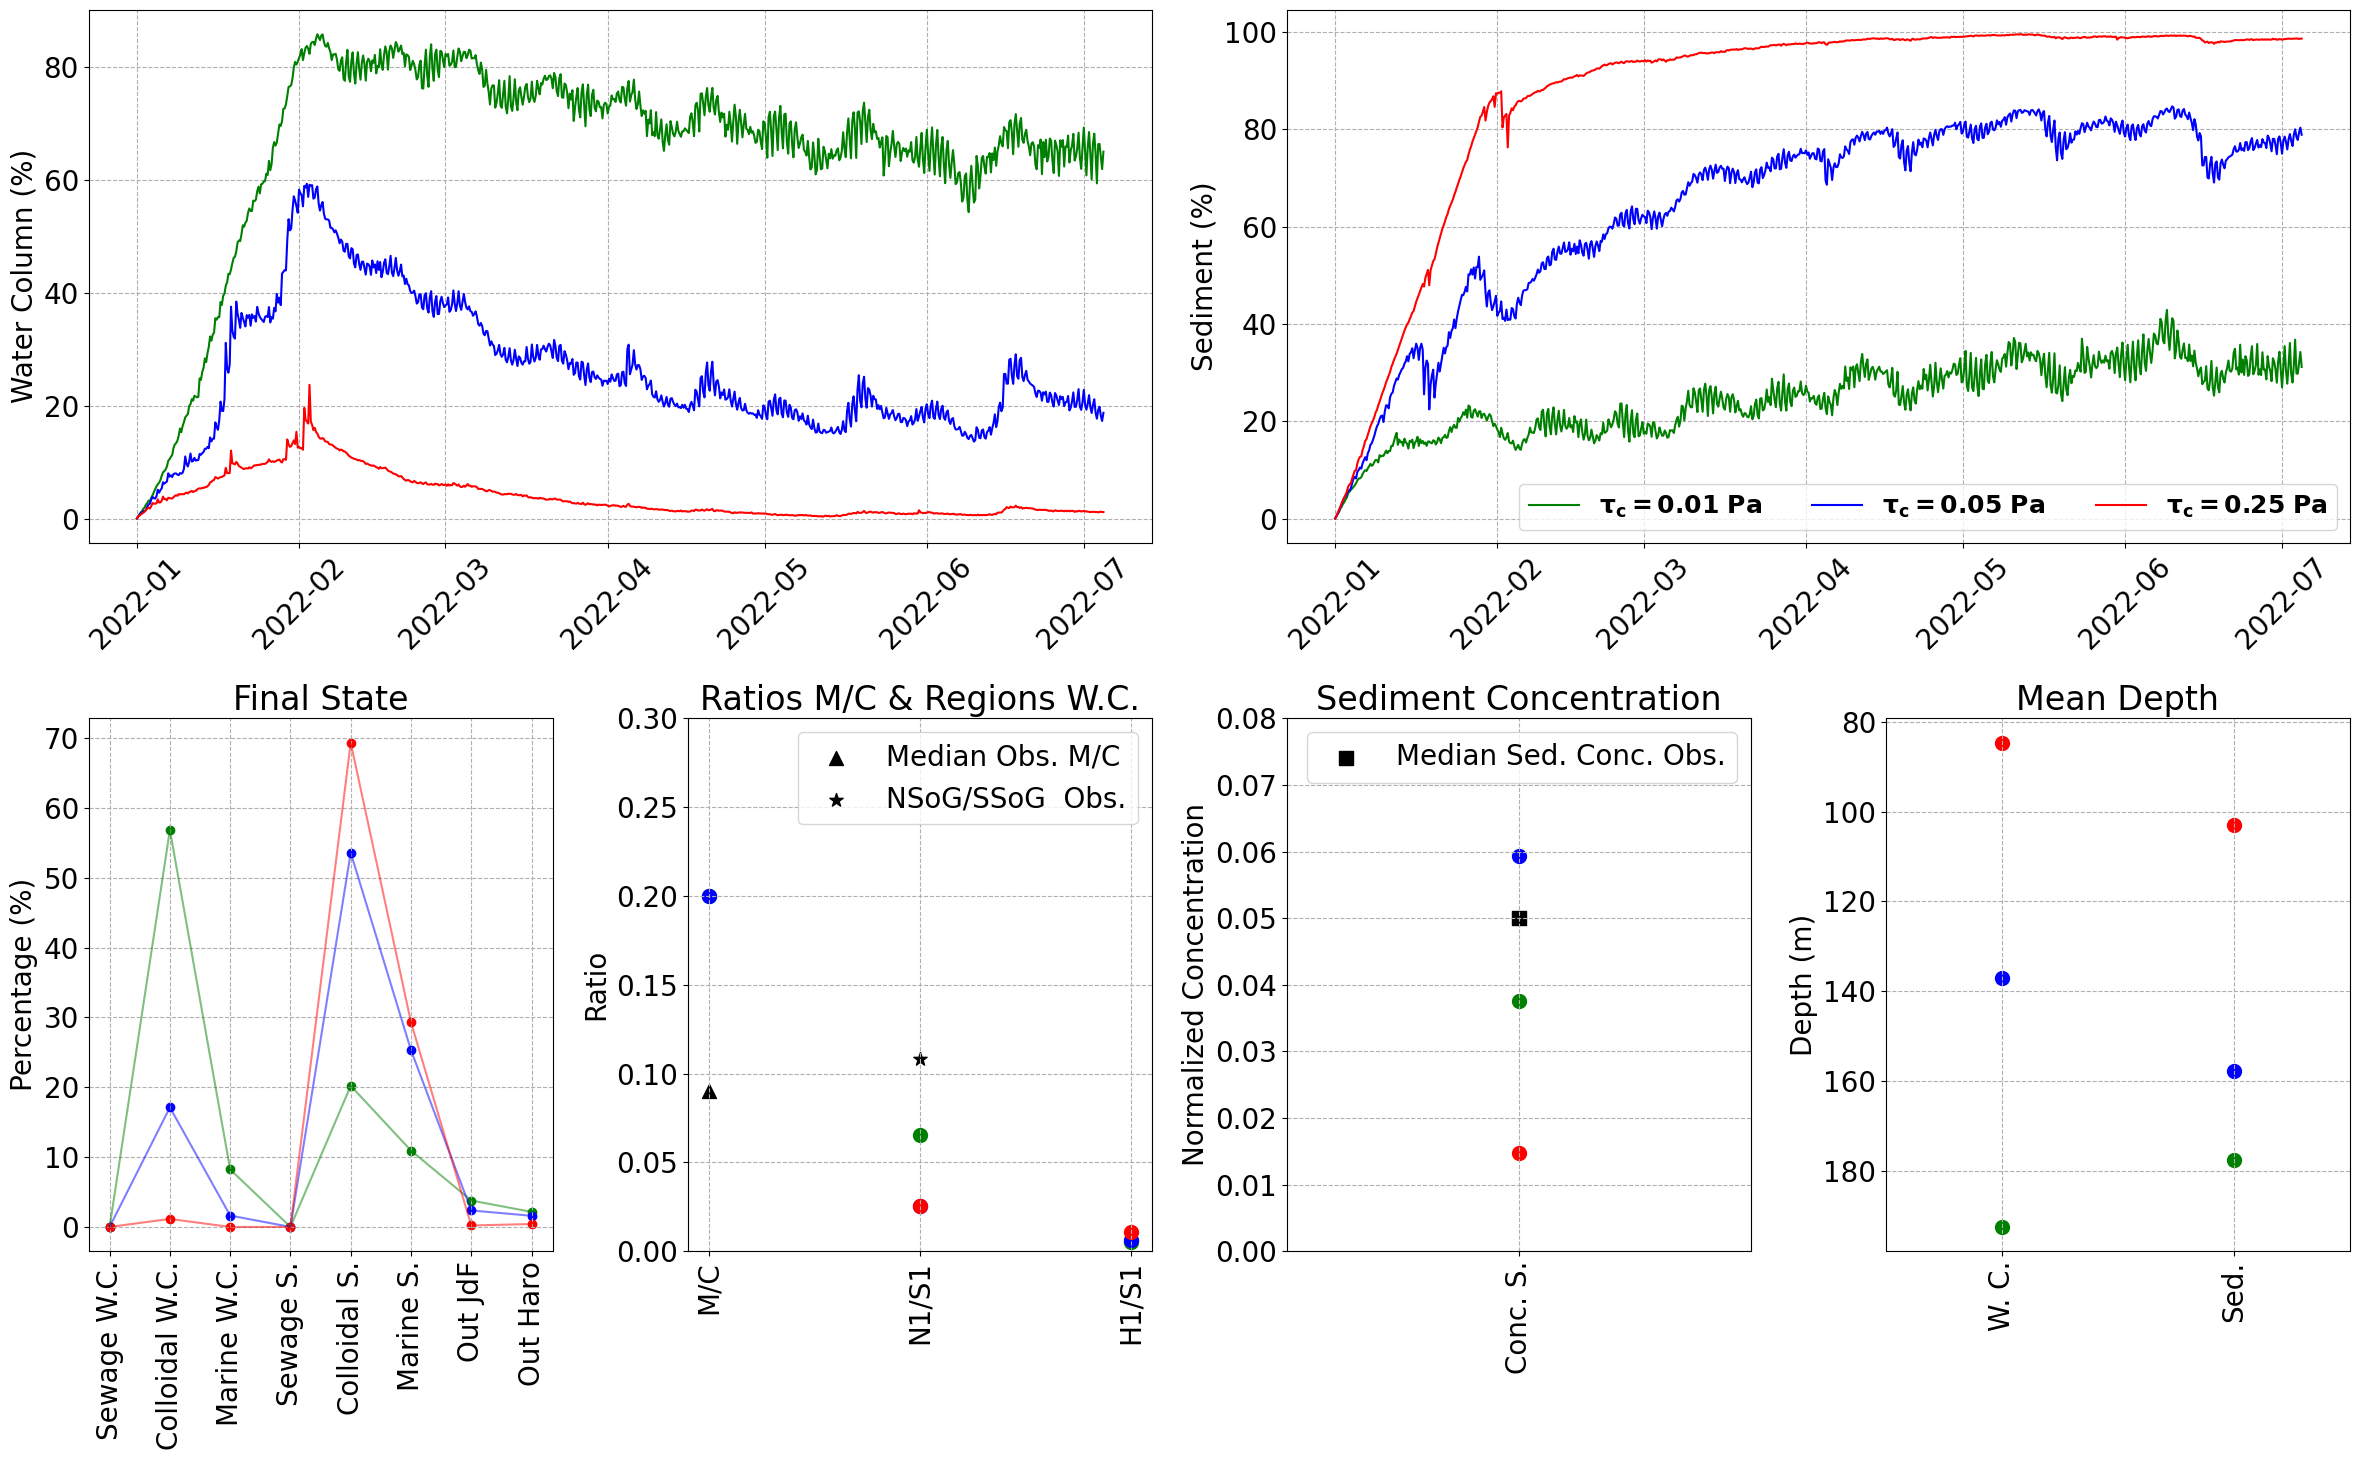

In [11]:
#
data_tau_0_01 = xr.open_zarr(filenames_tau_testing[0])
wc_tau_0_01 = data_tau_0_01.where((data_tau_0_01.status < 4)& (data_tau_0_01.status > 0))
sed_tau_0_01 = data_tau_0_01.where((data_tau_0_01.status > 10))
data_tau_0_05 = xr.open_zarr(filenames_tau_testing[1])
wc_tau_0_05 = data_tau_0_05.where((data_tau_0_05.status < 4)& (data_tau_0_05.status > 0))
sed_tau_0_05 = data_tau_0_05.where((data_tau_0_05.status > 10))
data_tau_0_25 = xr.open_zarr(filenames_tau_testing[2])
wc_tau_0_25 = data_tau_0_25.where((data_tau_0_25.status < 4)& (data_tau_0_25.status > 0))
sed_tau_0_25 = data_tau_0_25.where((data_tau_0_25.status > 10))
#
# === Plotting ===

fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(2, 8, height_ratios=[1,1])

# === Top row (2 panels) ===
ax1 = fig.add_subplot(gs[0, 0:4])
ax2 = fig.add_subplot(gs[0, 4:8])

# === Middle row (3 panels) ===
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])
ax6 = fig.add_subplot(gs[1, 6:8])

# === Top plots ===
ax1.plot(water_tau_0_01, 'g', label=rf"$\bf{{\tau_c = 0.01\ Pa}}$")
ax1.plot(water_tau_0_05, 'b', label=rf"$\bf{{\tau_c = 0.05\ Pa}}$")
ax1.plot(water_tau_0_25, 'r', label=rf"$\bf{{\tau_c = 0.25\ Pa}}$")
ax1.grid(linestyle='--')
ax1.set_ylabel('Water Column (%)')
ax1.tick_params(axis='x', rotation=45)

ax2.plot(sediment_tau_0_01, 'g', label=rf"$\bf{{\tau_c = 0.01\ Pa}}$")
ax2.plot(sediment_tau_0_05, 'b', label=rf"$\bf{{\tau_c = 0.05\ Pa}}$")
ax2.plot(sediment_tau_0_25, 'r', label=rf"$\bf{{\tau_c = 0.25\ Pa}}$")
ax2.grid(linestyle='--')
ax2.set_ylabel('Sediment (%)')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc = 'lower right', ncol = 3, fontsize = 18)

# --- Middle plots ---
# Middle left
ax3.scatter(run_tau_0_01.columns[1:], run_tau_0_01.iloc[-1][1:].values, c='g')
ax3.scatter(run_tau_0_05.columns[1:], run_tau_0_05.iloc[-1][1:].values, c='b')
ax3.scatter(run_tau_0_25.columns[1:], run_tau_0_25.iloc[-1][1:].values, c='r')
#
ax3.plot(run_tau_0_01.columns[1:], run_tau_0_01.iloc[-1][1:].values, color='g', alpha = .5)
ax3.plot(run_tau_0_05.columns[1:], run_tau_0_05.iloc[-1][1:].values, color='b', alpha = .5)
ax3.plot(run_tau_0_25.columns[1:], run_tau_0_25.iloc[-1][1:].values, color='r', alpha = .5)
ax3.grid(linestyle='--')
ax3.tick_params(axis='x', rotation=90)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Final State')

# Middle center
ax4.scatter(table_tau_0_01.columns[[1,3,4]], table_tau_0_01.loc[0].values[[1,3,4]], color='g', s=100)
ax4.scatter(table_tau_0_05.columns[[1,3,4]], table_tau_0_05.loc[0].values[[1,3,4]], color='b', s=100)
ax4.scatter(table_tau_0_25.columns[[1,3,4]], table_tau_0_25.loc[0].values[[1,3,4]], color='r', s=100)
ax4.scatter(table_tau_0_01.columns[1], 0.09, c='k', marker = '^', s = 100, label = 'Median Obs. M/C')
ax4.scatter(table_tau_0_01.columns[3], 0.108, c='k', marker = '*', s = 100, label = 'NSoG/SSoG  Obs.')
ax4.grid(linestyle='--')
ax4.tick_params(axis='x', rotation=90)
ax4.legend()
ax4.set_ylabel('Ratio')
ax4.set_title('Ratios M/C & Regions W.C.')
ax4.set_ylim([0, 0.3])


#
ax5.scatter(table_tau_0_01.columns[2], table_tau_0_01.loc[0].values[2], color='g', s=100)
ax5.scatter(table_tau_0_05.columns[2], table_tau_0_05.loc[0].values[2], color='b', s=100)
ax5.scatter(table_tau_0_25.columns[2], table_tau_0_25.loc[0].values[2], color='r', s=100)
ax5.scatter(table_tau_0_01.columns[2], 0.05, c='k', marker = 's', s = 100, label = 'Median Sed. Conc. Obs.') # Median of normalized obs. concentrations
ax5.grid(linestyle='--')
ax5.legend()
ax5.tick_params(axis='x', rotation=90)
ax5.set_ylabel('Normalized Concentration')
ax5.set_ylim([0, 0.08])
ax5.set_title('Sediment Concentration')


# Middle right
ax6.scatter(table_tau_0_01.columns[-2:], table_tau_0_01.loc[0].values[-2:], color='g', s=100)
ax6.scatter(table_tau_0_05.columns[-2:], table_tau_0_05.loc[0].values[-2:], color='b', s=100)
ax6.scatter(table_tau_0_25.columns[-2:], table_tau_0_25.loc[0].values[-2:], color='r', s=100)
ax6.grid(linestyle='--')
ax6.set_xlim([-.5, 1.5])
ax6.tick_params(axis='x', rotation=90)
ax6.invert_yaxis()
ax6.set_ylabel('Depth (m)')
ax6.set_title('Mean Depth')

#
#
plt.tight_layout()

plt.show()

In [12]:
table_tau_0_25.loc[0].values[1]

0.4999999999999999

Filenames for Marine Sinking Velocity Testing:

- Marine Sinking Vel. = 2 m/hr

- Marine Sinking Vel. = 5.52 m/hr

- Marine Sinking Vel. = 12 m/hr

Keep Ratio MC = 0.2 and $\tau = 0.01 Pa$

In [3]:
filenames_marine_sinkvel_testing = ['/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_185_days_full_updated_kernel_marine_sinkvel_2.zarr',
                                    '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_185_days_full_updated_kernel_ratio_0_2.zarr',
                                    '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112022_run_185_days_full_updated_kernel_marine_sinkvel_12.zarr']

In [4]:
run_marine_sinkvel_2 = proportions_from_filename(filename = filenames_marine_sinkvel_testing[0])
run_marine_sinkvel_5 = proportions_from_filename(filename = filenames_marine_sinkvel_testing[1])
run_marine_sinkvel_12 = proportions_from_filename(filename = filenames_marine_sinkvel_testing[2])
#
table_marine_sinkvel_2  = metrics_table(filename = filenames_marine_sinkvel_testing[0], plot = False)
table_marine_sinkvel_5  = metrics_table(filename = filenames_marine_sinkvel_testing[1], plot = False)
table_marine_sinkvel_12  = metrics_table(filename = filenames_marine_sinkvel_testing[2], plot = False)

In [5]:
water_marine_sinkvel_2, sediment_marine_sinkvel_2 =  run_marine_sinkvel_2['Sewage W.C.'] + run_marine_sinkvel_2['Colloidal W.C.'] + run_marine_sinkvel_2['Marine W.C.'] , run_marine_sinkvel_2['Sewage S.'] + run_marine_sinkvel_2['Colloidal S.'] + run_marine_sinkvel_2['Marine S.']
water_marine_sinkvel_5, sediment_marine_sinkvel_5 =  run_marine_sinkvel_5['Sewage W.C.'] + run_marine_sinkvel_5['Colloidal W.C.'] + run_marine_sinkvel_5['Marine W.C.'] , run_marine_sinkvel_5['Sewage S.'] + run_marine_sinkvel_5['Colloidal S.'] + run_marine_sinkvel_5['Marine S.']
water_marine_sinkvel_12, sediment_marine_sinkvel_12 =  run_marine_sinkvel_12['Sewage W.C.'] + run_marine_sinkvel_12['Colloidal W.C.'] + run_marine_sinkvel_12['Marine W.C.'] , run_marine_sinkvel_12['Sewage S.'] + run_marine_sinkvel_12['Colloidal S.'] + run_marine_sinkvel_12['Marine S.']

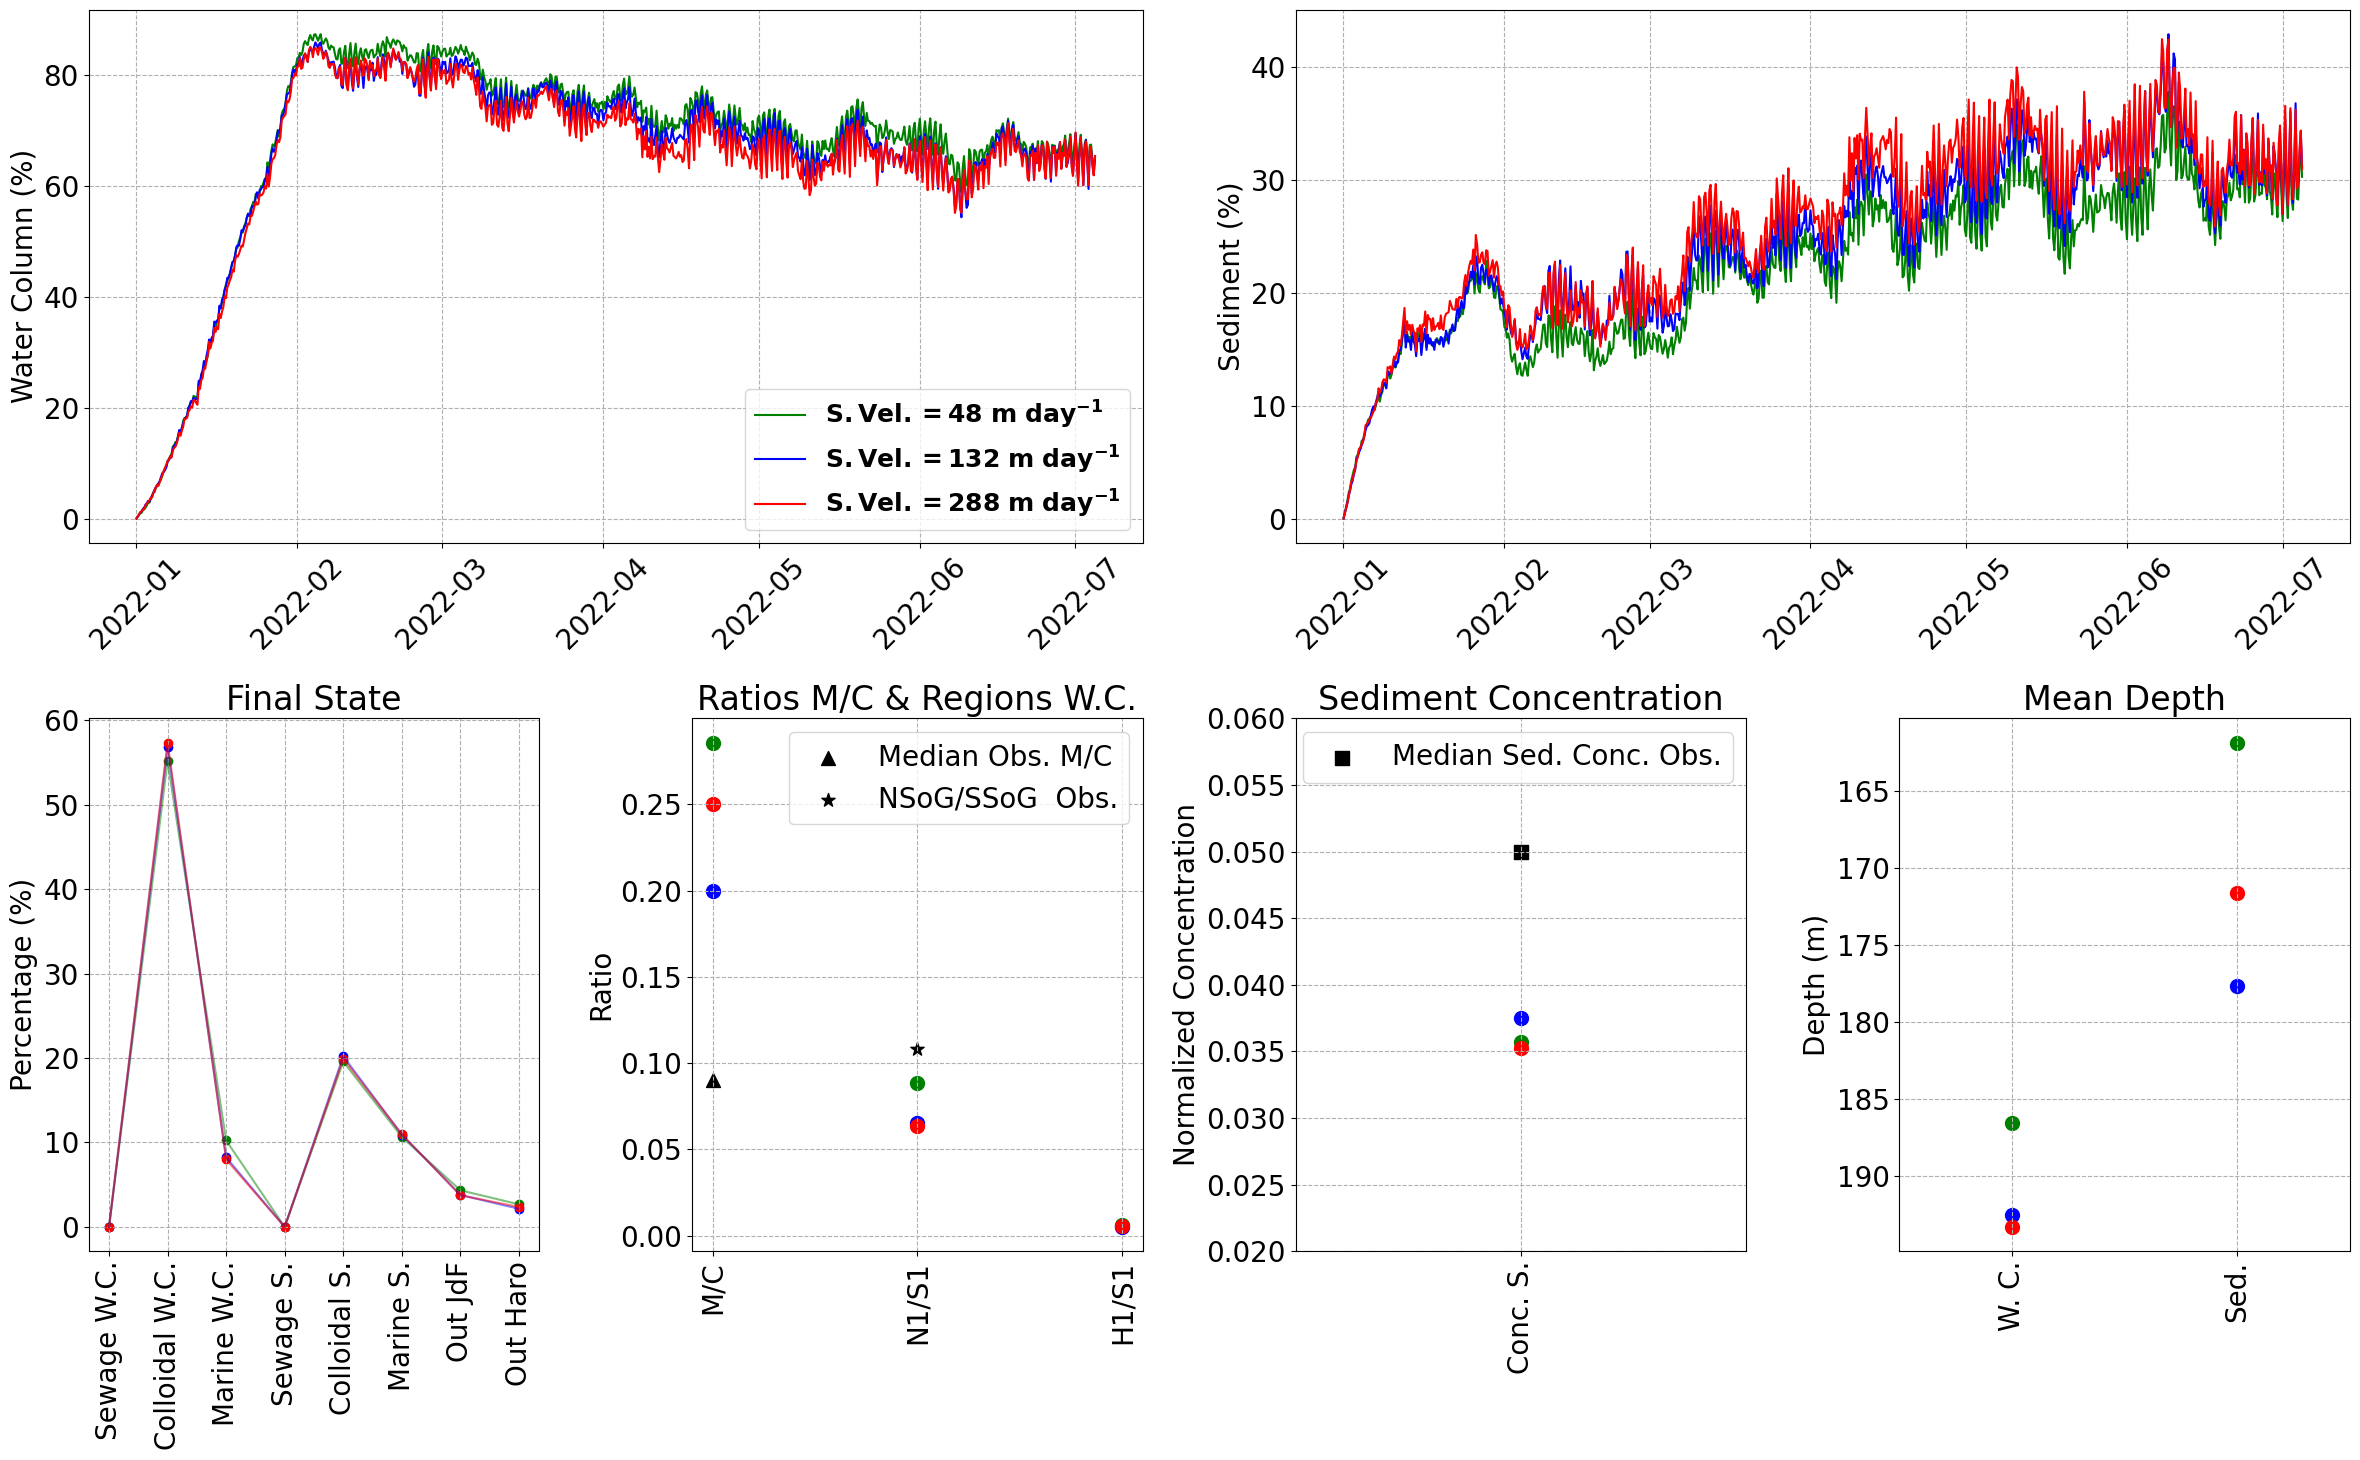

In [8]:
plt.rcParams.update({'font.size': 20})
#
data_marine_sinkvel_2 = xr.open_zarr(filenames_marine_sinkvel_testing[0])
wc_marine_sinkvel_2 = data_marine_sinkvel_2.where((data_marine_sinkvel_2.status < 4)& (data_marine_sinkvel_2.status > 0))
sed_marine_sinkvel_2 = data_marine_sinkvel_2.where((data_marine_sinkvel_2.status > 10))
data_marine_sinkvel_5 = xr.open_zarr(filenames_marine_sinkvel_testing[1])
wc_marine_sinkvel_5 = data_marine_sinkvel_5.where((data_marine_sinkvel_5.status < 4)& (data_marine_sinkvel_5.status > 0))
sed_marine_sinkvel_5 = data_marine_sinkvel_5.where((data_marine_sinkvel_5.status > 10))
data_marine_sinkvel_12 = xr.open_zarr(filenames_marine_sinkvel_testing[2])
wc_marine_sinkvel_12 = data_marine_sinkvel_12.where((data_marine_sinkvel_12.status < 4)& (data_marine_sinkvel_12.status > 0))
sed_marine_sinkvel_12 = data_marine_sinkvel_12.where((data_marine_sinkvel_12.status > 10))
#

fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(2, 8, height_ratios=[1,1])

# === Top row (2 panels) ===
ax1 = fig.add_subplot(gs[0, 0:4])
ax2 = fig.add_subplot(gs[0, 4:8])

# === Middle row (3 panels) ===
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])
ax6 = fig.add_subplot(gs[1, 6:8])

# === Plotting ===

# Top left
ax1.plot(water_marine_sinkvel_2, 'g', label=rf"$\mathbf{{S. Vel. = 48\ m\ day^{{-1}}}}$")
ax1.plot(water_marine_sinkvel_5, 'b', label=rf"$\mathbf{{S. Vel. = 132\ m\ day^{{-1}}}}$")
ax1.plot(water_marine_sinkvel_12, 'r', label=rf"$\mathbf{{S. Vel. = 288\ m\ day^{{-1}}}}$")
ax1.grid(linestyle='--')
ax1.legend(loc = 'lower right', fontsize = 18)
ax1.set_ylabel('Water Column (%)')
ax1.tick_params(axis='x', rotation=45)

# Top right
ax2.plot(sediment_marine_sinkvel_2, 'g', label=rf"$\mathbf{{S. Vel. = 48\ m\ day^{{-1}}}}$")
ax2.plot(sediment_marine_sinkvel_5, 'b', label=rf"$\mathbf{{S. Vel. = 132\ m\ day^{{-1}}}}$")
ax2.plot(sediment_marine_sinkvel_12, 'r', label=rf"$\mathbf{{S. Vel. = 288\ m\ day^{{-1}}}}$")
ax2.grid(linestyle='--')
ax2.set_ylabel('Sediment (%)')
ax2.tick_params(axis='x', rotation=45)

# --- Middle plots ---
# Middle left
ax3.scatter(run_marine_sinkvel_2.columns[1:], run_marine_sinkvel_2.iloc[-1][1:].values, c='g')
ax3.scatter(run_marine_sinkvel_5.columns[1:], run_marine_sinkvel_5.iloc[-1][1:].values, c='b')
ax3.scatter(run_marine_sinkvel_12.columns[1:], run_marine_sinkvel_12.iloc[-1][1:].values, c='r')
#
ax3.plot(run_marine_sinkvel_2.columns[1:], run_marine_sinkvel_2.iloc[-1][1:].values, color='g', alpha = .5)
ax3.plot(run_marine_sinkvel_5.columns[1:], run_marine_sinkvel_5.iloc[-1][1:].values, color='b', alpha = .5)
ax3.plot(run_marine_sinkvel_12.columns[1:], run_marine_sinkvel_12.iloc[-1][1:].values, color='r', alpha = .5)
ax3.grid(linestyle='--')
ax3.tick_params(axis='x', rotation=90)
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Final State')

# Middle center
ax4.scatter(table_marine_sinkvel_2.columns[[1,3,4]], table_marine_sinkvel_2.loc[0].values[[1,3,4]], color='g', s=100)
ax4.scatter(table_marine_sinkvel_5.columns[[1,3,4]], table_marine_sinkvel_5.loc[0].values[[1,3,4]], color='b', s=100)
ax4.scatter(table_marine_sinkvel_12.columns[[1,3,4]], table_marine_sinkvel_12.loc[0].values[[1,3,4]], color='r', s=100)
ax4.scatter(table_marine_sinkvel_2.columns[1], 0.09, c='k', marker = '^', s = 100, label = 'Median Obs. M/C')
ax4.scatter(table_marine_sinkvel_2.columns[3], 0.108, c='k', marker = '*', s = 100, label = 'NSoG/SSoG  Obs.')
ax4.grid(linestyle='--')
ax4.tick_params(axis='x', rotation=90)
ax4.legend()
ax4.set_ylabel('Ratio')
ax4.set_title('Ratios M/C & Regions W.C.')

#
ax5.scatter(table_marine_sinkvel_2.columns[2], table_marine_sinkvel_2.loc[0].values[2], color='g', s=100)
ax5.scatter(table_marine_sinkvel_5.columns[2], table_marine_sinkvel_5.loc[0].values[2], color='b', s=100)
ax5.scatter(table_marine_sinkvel_12.columns[2], table_marine_sinkvel_12.loc[0].values[2], color='r', s=100)
ax5.scatter(table_marine_sinkvel_2.columns[2], 0.05, c='k', marker = 's', s = 100, label = 'Median Sed. Conc. Obs.') # Median of normalized obs. concentrations
ax5.grid(linestyle='--')
ax5.legend()
ax5.tick_params(axis='x', rotation=90)
ax5.set_ylabel('Normalized Concentration')
ax5.set_ylim([0.02, 0.06])
ax5.set_title('Sediment Concentration')


# Middle right
ax6.scatter(table_marine_sinkvel_2.columns[-2:], table_marine_sinkvel_2.loc[0].values[-2:], color='g', s=100)
ax6.scatter(table_marine_sinkvel_5.columns[-2:], table_marine_sinkvel_5.loc[0].values[-2:], color='b', s=100)
ax6.scatter(table_marine_sinkvel_12.columns[-2:], table_marine_sinkvel_12.loc[0].values[-2:], color='r', s=100)
ax6.grid(linestyle='--')
ax6.set_xlim([-.5, 1.5])
ax6.tick_params(axis='x', rotation=90)
ax6.invert_yaxis()
ax6.set_ylabel('Depth (m)')
ax6.set_title('Mean Depth')

#
#
plt.tight_layout()

plt.show()

We may need to define another way of pushing particles from the bottom. Beacause, with this set up, changing the Sinking Velocity of marine particles does not affect the simulation results

# Final Version

In [2]:
filename = '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Simulations_runs/PBDE_particles_for_0112018_run_365_days_full_release_export_kernels_added.zarr'
#
run_final = proportions_from_filename(filename = filename)
#
table_final = metrics_table(filename = filename, plot = False)
#
water_final, sediment_final =  run_final['Sewage Water'] + run_final['Colloidal Water'] + run_final['Marine Water'] , run_final['Sewage Sediment'] + run_final['Colloidal Sediment'] + run_final['Marine Sediment']


In [3]:
#
data_final = xr.open_dataset(filename, engine = 'zarr')
wc_final = data_final.where((data_final.status < 4)& (data_final.status > 0))
sed_final = data_final.where((data_final.status > 10))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


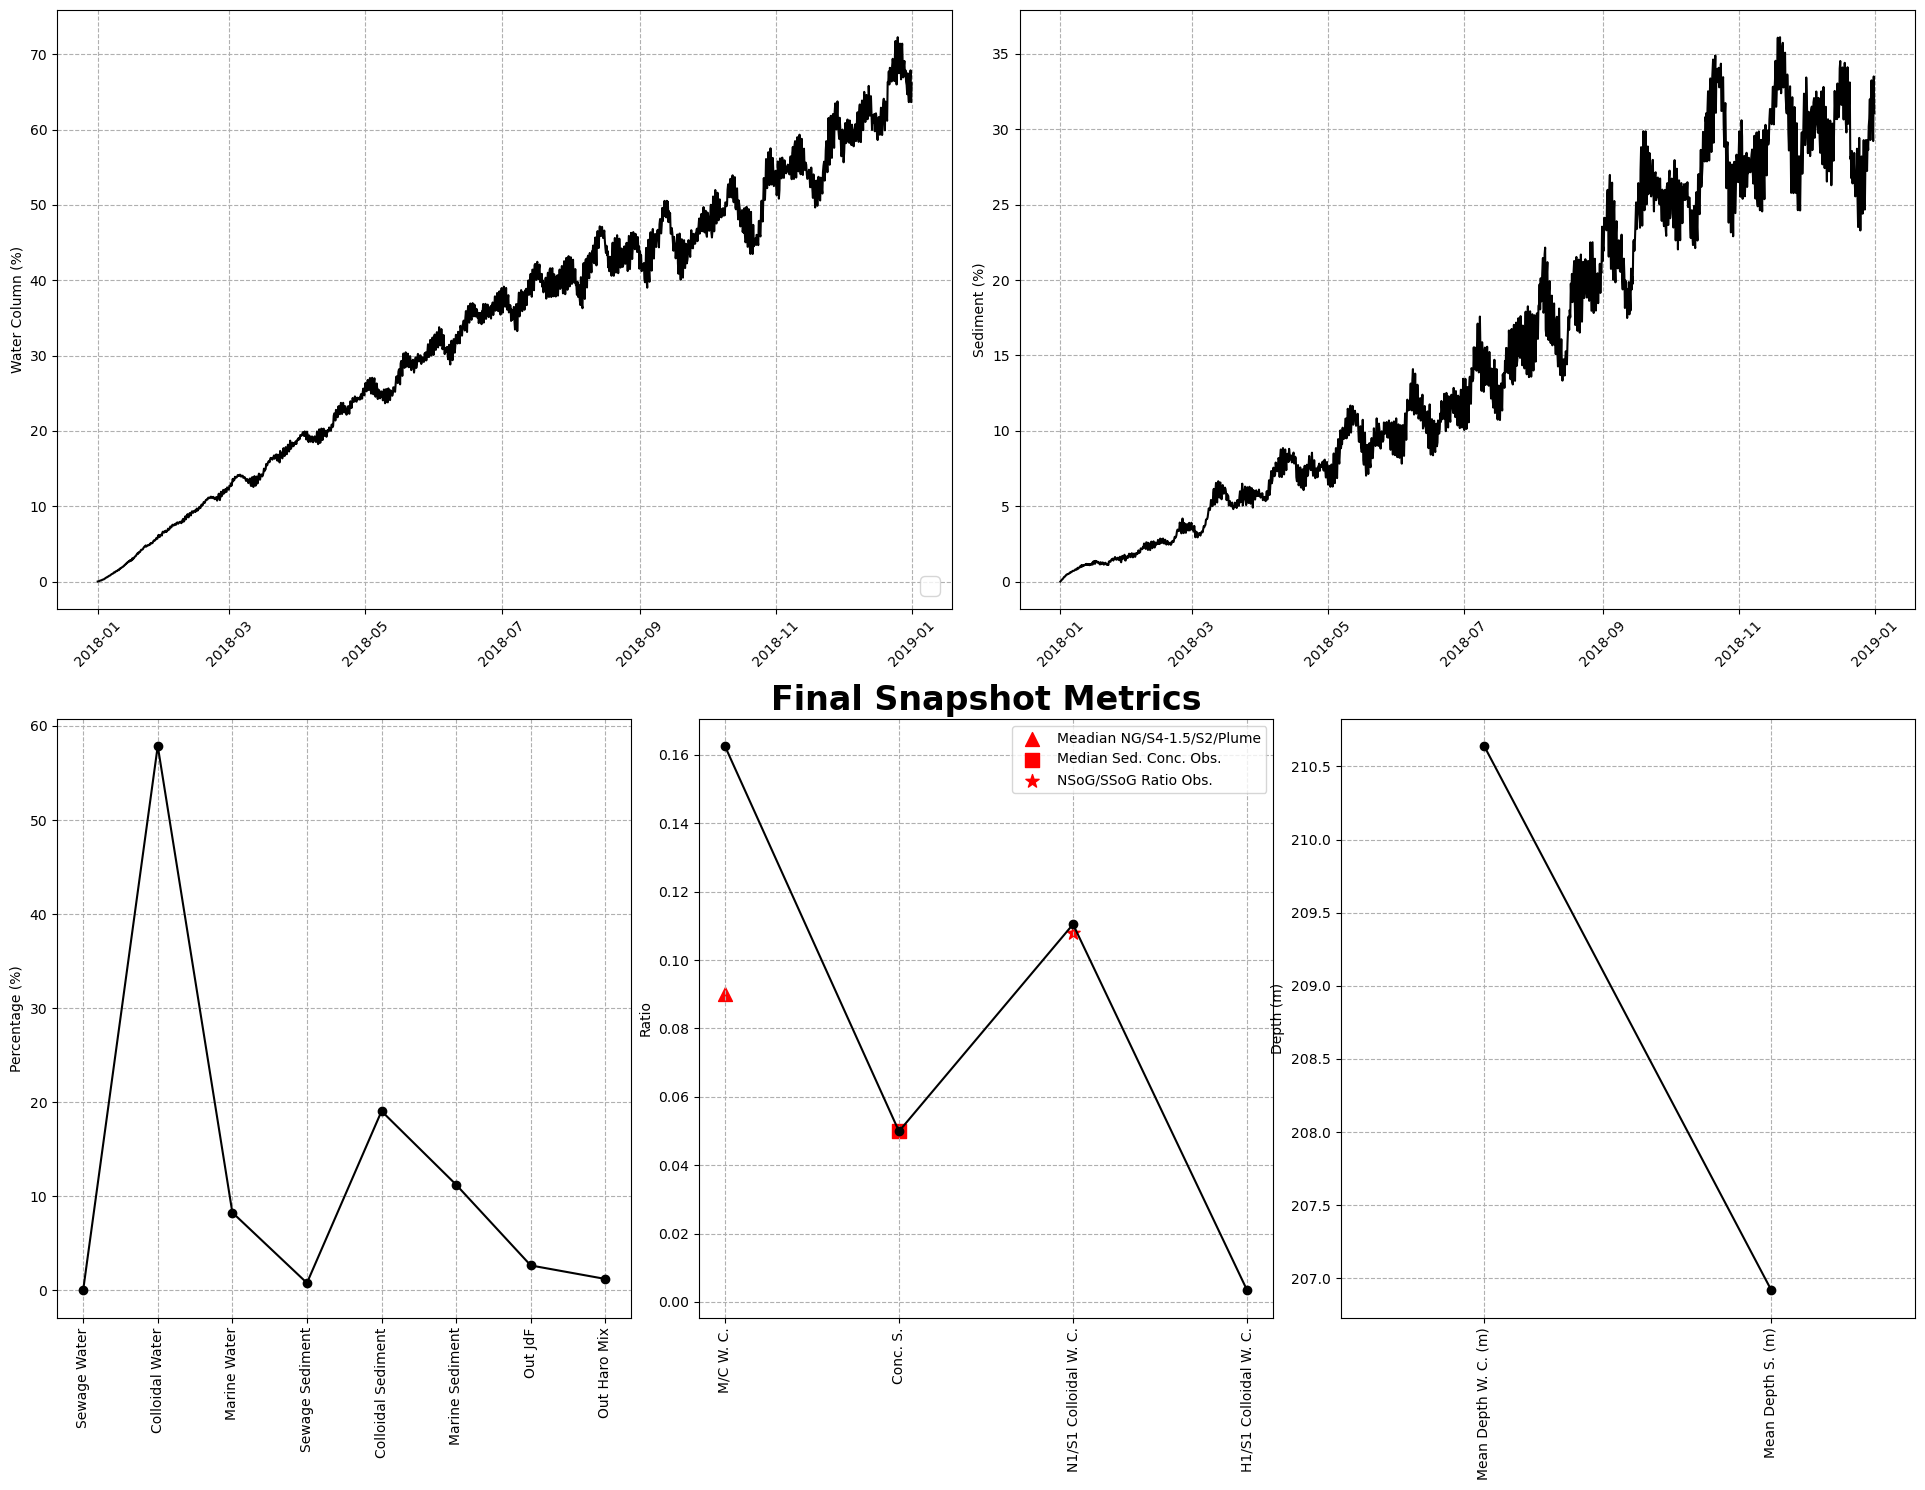

In [ ]:
fig = plt.figure(figsize=(24, 15))
gs = gridspec.GridSpec(2, 6, height_ratios=[1,1])

# === Top row (2 panels) ===
ax1 = fig.add_subplot(gs[0, 0:3])
ax2 = fig.add_subplot(gs[0, 3:6])

# === Middle row (3 panels) ===
ax3 = fig.add_subplot(gs[1, 0:2])
ax4 = fig.add_subplot(gs[1, 2:4])
ax5 = fig.add_subplot(gs[1, 4:6])

# === Plotting ===

# Top left
ax1.plot(water_final, 'k')
ax1.grid(linestyle='--')
ax1.legend(loc = 'lower right', fontsize = 18)
ax1.set_ylabel('Water Column (%)')
ax1.tick_params(axis='x', rotation=45)

# Top right
ax2.plot(sediment_final, 'k')
ax2.grid(linestyle='--')
ax2.set_ylabel('Sediment (%)')
ax2.tick_params(axis='x', rotation=45)

# Middle left
ax3.plot(run_final.columns[1:], run_final.iloc[-1][1:].values, '-o', color='k')
ax3.grid(linestyle='--')
ax3.tick_params(axis='x', rotation=90)
ax3.set_ylabel('Percentage (%)')

# Middle center
ax4.plot(table_final.columns[1:5], table_final.loc[0].values[1:5], '-o', color='k')
ax4.scatter(table_final.columns[1], 0.09, c='r', marker = '^', s = 100, label = 'Meadian NG/S4-1.5/S2/Plume')
ax4.scatter(table_final.columns[2], 0.05, c='r', marker = 's', s = 100, label = 'Median Sed. Conc. Obs.') # Median of normalized obs. concentrations
ax4.scatter(table_final.columns[3], 0.108, c='r', marker = '*', s = 100, label = 'NSoG/SSoG Ratio Obs.')
ax4.grid(linestyle='--')
ax4.tick_params(axis='x', rotation=90)
ax4.set_ylabel('Ratio')
ax4.set_title('Final Snapshot Metrics', fontweight='bold', fontsize=24)
ax4.legend()

# Middle right
ax5.plot(table_final.columns[-2:], table_final.loc[0].values[-2:], '-o', color='k')
ax5.grid(linestyle='--')
ax5.tick_params(axis='x', rotation=90)
ax5.set_ylabel('Depth (m)')
ax5.set_xlim([-.5,1.5])
#

 
plt.tight_layout()
plt.subplots_adjust(right=0.8)
plt.show()


In [19]:
water_final.mean() / sediment_final.mean()

2.2622112901056606

In [10]:
P_ratio = 0.27
S2 = 0.06
S4_15 = (0.012 + 0.011) / 2
NG = (0.07 + 0.2) / 2

In [14]:
R_obs = np.mean([P_ratio, S2, S4_15, NG])
print(R_obs)

0.11912500000000001


In [8]:
ratios = [0.27, 0.06, 0.012, 0.011, 0.07, 0.2]
#
# Better to have a concentration in the water column instead of ratio? Better to keep the ratios for the regions ?
# Median of normalized observations of sediment concentrations
# 0.050399608546729736

In [ ]:
# Median ratio of M/C considering NG, S4-1.5 and S1-S2 regions
Ratio_MC_obs = 0.09

In [9]:
np.mean(ratios)

0.10383333333333333